In [19]:
import os
import json
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

In [5]:
def evaluate_data(data):
    operator_counts = {'AND': 0, 'OR': 0, 'NOT': 0} 
    ic_count = ec_count = 0

    def recurse_entries(section_data):
        nonlocal ic_count, ec_count
        if isinstance(section_data, dict):
            for key, value in section_data.items():
                if key.startswith('IC'):
                    ic_count += 1
                if key.startswith('EC'):
                    ec_count += 1
                if key == 'operators' and isinstance(value, list):
                    for operator in value:
                        if operator in operator_counts:
                            operator_counts[operator] += 1
                if isinstance(value, dict):
                    recurse_entries(value)
                elif isinstance(value, list):
                    for item in value:
                        if isinstance(item, dict):
                            recurse_entries(item)

    if 'IC' in data:
        recurse_entries(data['IC'])
    if 'EC' in data:
        recurse_entries(data['EC'])

    return {
        "ic_count": ic_count,
        "ec_count": ec_count,
        **operator_counts  # Entpackt die Operatorenwerte in das Hauptwörterbuch
    }

def read_and_evaluate_files(input_directory, output_directory, csv_name):
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    results_list = []

    for filename in os.listdir(input_directory):
        if filename.endswith(".json"):
            print(filename)
        # nct_number = filename.split("_")[0].split(".")[0]  # FÜR CHIA Daten
            nct_number = filename.split("_")[1]
            
            filepath = os.path.join(input_directory, filename)
            with open(filepath, 'r', encoding='utf-8') as file:
                data = json.load(file)
                results = evaluate_data(data)
                results['nct_number'] = nct_number
                results_list.append(results)

                # JSON speichern
                #output_filepath = os.path.join(output_directory, filename.replace(".json", "_eval.json"))
                #with open(output_filepath, 'w', encoding='utf-8') as output_file:
                #    json.dump(results, output_file, indent=4)
    
    # Erstellen eines DataFrame und Speichern als CSV
    df = pd.DataFrame(results_list)
    df.set_index('nct_number', inplace=True)
    df.to_csv(os.path.join(output_directory, csv_name))
    return df

#### Evaluierung der ChIA-Daten

In [8]:
csv_name = 'chia_label.csv'
input_directory = "/work/eauten2s/ec_criteria_struct/datasets/Chia/transform_chia/output/struct" #'../output/struct'
df = read_and_evaluate_files(input_directory, "ergebnisse", csv_name)

NCT00050349.json


IndexError: list index out of range

In [34]:
df

,ic_count,ec_count,AND,OR,NOT
nct_number,,,,,
NCT00050349,26,51,12,28,6
NCT00061308,11,30,4,11,2
NCT00094861,51,48,6,32,4
NCT00122070,6,16,1,5,0
NCT00182520,19,18,3,18,0
...,...,...,...,...,...
NCT03637946,17,12,1,8,1
NCT03639519,2,17,3,1,0
NCT03639545,1,8,0,2,0


#### Evaluierung der Llama3-Instruct-3-shot-Daten

In [12]:
csv_llama = 'llama3_inst_3_shot.csv'
input_directory = '../output/struct'
label_directory = 'chia_eval'
llama3_output = 'llama3_inst_3_shot'
model_eval_directory = 'llama3_inst_3_shot_eval'
df_llama = read_and_evaluate_files(llama3_output, "ergebnisse", csv_llama)

Llama-3-8B-Instruct_NCT00050349_3_shot.json
Llama-3-8B-Instruct_NCT00061308_3_shot.json
Llama-3-8B-Instruct_NCT00094861_3_shot.json
Llama-3-8B-Instruct_NCT00122070_3_shot.json
Llama-3-8B-Instruct_NCT00182520_3_shot.json
Llama-3-8B-Instruct_NCT00183885_3_shot.json
Llama-3-8B-Instruct_NCT00198913_3_shot.json
Llama-3-8B-Instruct_NCT00235170_3_shot.json
Llama-3-8B-Instruct_NCT00236340_3_shot.json
Llama-3-8B-Instruct_NCT00250640_3_shot.json
Llama-3-8B-Instruct_NCT00279552_3_shot.json
Llama-3-8B-Instruct_NCT00305097_3_shot.json
Llama-3-8B-Instruct_NCT00312429_3_shot.json
Llama-3-8B-Instruct_NCT00317148_3_shot.json
Llama-3-8B-Instruct_NCT00319748_3_shot.json
Llama-3-8B-Instruct_NCT00324363_3_shot.json
Llama-3-8B-Instruct_NCT00343668_3_shot.json
Llama-3-8B-Instruct_NCT00344318_3_shot.json
Llama-3-8B-Instruct_NCT00351611_3_shot.json
Llama-3-8B-Instruct_NCT00356148_3_shot.json
Llama-3-8B-Instruct_NCT00379366_3_shot.json
Llama-3-8B-Instruct_NCT00391690_3_shot.json
Llama-3-8B-Instruct_NCT00396734_

In [13]:
df_llama

,ic_count,ec_count,AND,OR,NOT
nct_number,,,,,
NCT00050349,20,32,6,17,0
NCT00061308,13,33,4,12,5
NCT00094861,32,34,0,0,0
NCT00122070,11,21,3,1,0
NCT00182520,21,18,8,15,0
...,...,...,...,...,...
NCT01218737,8,17,0,9,0
NCT01228279,5,26,12,0,0
NCT01236417,10,19,7,2,0


In [9]:
true_data_path = 'ergebnisse/chia_label.csv'
predicted_data_path = 'ergebnisse/llama3_inst_3_shot.csv'

# Daten laden
true_data = pd.read_csv(true_data_path)
predicted_data = pd.read_csv(predicted_data_path)

# Daten anhand der NCT-Nummer zusammenführen
merged_data = pd.merge(true_data, predicted_data, on='nct_number', suffixes=('_true', '_pred'))

# Metriken für jede Kategorie berechnen
categories = ['ic_count', 'ec_count', 'AND', 'OR', 'NOT']
metrics = {}

for category in categories:
    true_values = merged_data[f'{category}_true']
    predicted_values = merged_data[f'{category}_pred']
    mae = mean_absolute_error(true_values, predicted_values)
    mse = mean_squared_error(true_values, predicted_values)
    metrics[category] = {'MAE': mae, 'MSE': mse}

# Ergebnisse ausgeben
print("Metriken für jede Kategorie:\n")
for category, values in metrics.items():
    print(f"{category} -> MAE: {values['MAE']:.2f}, MSE: {values['MSE']:.2f}")

Metriken für jede Kategorie:

ic_count -> MAE: 5.36, MSE: 62.80
ec_count -> MAE: 7.46, MSE: 171.64
AND -> MAE: 3.95, MSE: 34.05
OR -> MAE: 6.93, MSE: 122.95
NOT -> MAE: 2.06, MSE: 12.36


In [28]:
df = merged_data
df

,nct_number,ic_count_true,ec_count_true,AND_true,OR_true,NOT_true,ic_count_pred,ec_count_pred,AND_pred,OR_pred,NOT_pred
0,NCT00050349,26,51,12,28,6,20,32,6,17,0
1,NCT00061308,11,30,4,11,2,13,33,4,12,5
2,NCT00094861,51,48,6,32,4,32,34,0,0,0
3,NCT00122070,6,16,1,5,0,11,21,3,1,0
4,NCT00182520,19,18,3,18,0,21,18,8,15,0
...,...,...,...,...,...,...,...,...,...,...,...
95,NCT01218737,9,24,3,15,0,8,17,0,9,0
96,NCT01228279,2,30,3,5,0,5,26,12,0,0
97,NCT01236417,8,16,0,6,0,10,19,7,2,0
98,NCT01261832,1,25,0,12,1,1,25,1,11,0


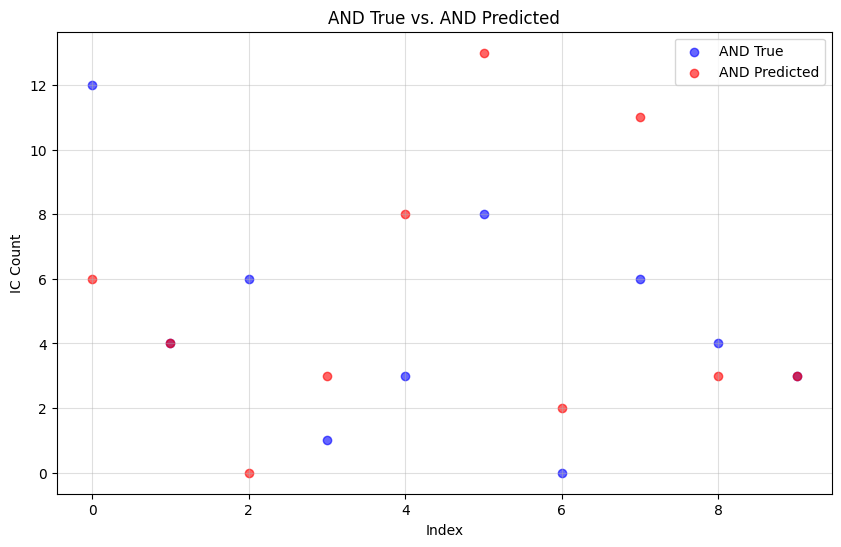

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(df.index[:10], df['AND_true'][:10], color='blue', label='AND True', alpha=0.6)
plt.scatter(df.index[:10], df['AND_pred'][:10], color='red', label='AND Predicted', alpha=0.6)
plt.xlabel('Index')
plt.ylabel('IC Count')
plt.title('AND True vs. AND Predicted')
plt.legend()
plt.grid(True, alpha=.4)
plt.show()

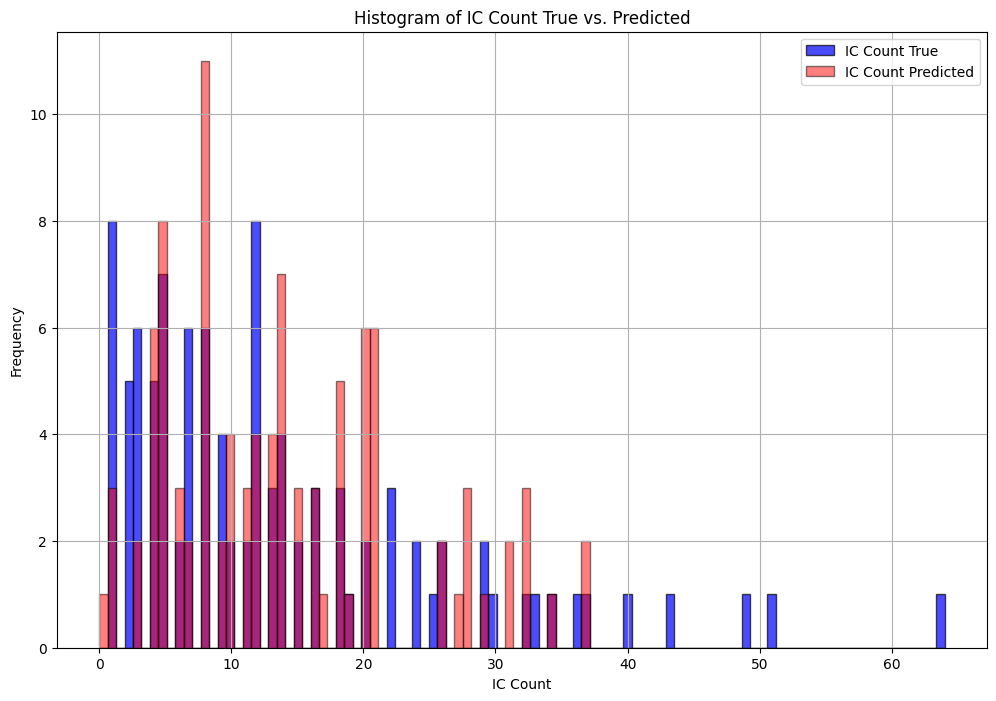

In [39]:
plt.figure(figsize=(12, 8))

data_true = df['ic_count_true']
data_pred = df['ic_count_pred']
bins = np.linspace(min(data_true.min(), data_pred.min()), max(data_true.max(), data_pred.max()), 101)

plt.hist(data_true,bins=bins, color='blue', alpha=0.7, label='IC Count True', edgecolor='black')
plt.hist(data_pred,bins=bins, color='red', alpha=0.5, label='IC Count Predicted', edgecolor='black')

plt.xlabel('IC Count')
plt.ylabel('Frequency')
plt.title('Histogram of IC Count True vs. Predicted')
plt.legend()
plt.grid(True)
plt.show()